In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d
import argparse
import pickle

from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
)

from triangular_transport.kernels.kernel_tools import (
    get_gaussianRBF,
    vectorize_kfunc,
    get_sum_of_kernels,
)

plt.style.use("ggplot")

/home/verano13/miniconda3/envs/stochastic-interpolants/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


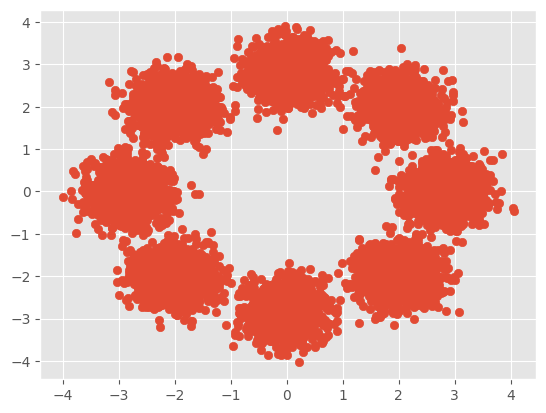

In [42]:
x1 = inf_train_gen(data="8gaussians", batch_size=10000)
plt.scatter(x1[:, 0], x1[:, 1])

In [67]:
def eight_gaussians_density(x):
    scale = 4.0
    centers = [
            (1, 0),
            (-1, 0),
            (0, 1),
            (0, -1),
            (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        ]
    centers = [(scale * x, scale * y) for x, y in centers]
    factor = 2 / np.pi
    y, u = x[0], x[1]
    norm_part = np.array([((y - mu1) ** 2) + (u - mu2) ** 2 for mu1, mu2 in centers], dtype="float32")
    exp_part = np.exp(-scale * norm_part)
    sum_part = np.sum(exp_part)
    return factor * sum_part

def eight_gaussians_cond(u):
    scale = 4.0
    u = np.asarray(u)
    if u.ndim > 0:
        u = u.item()
    y = cond_variable
    y = float(np.asarray(y).item())
    centers = [
            (1, 0),
            (-1, 0),
            (0, 1),
            (0, -1),
            (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
            (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        ]
    centers = np.array([((scale * x) / np.sqrt(2), (scale * y) / (np.sqrt(2))) for x, y in centers], dtype="float32")
    factor = 1 / np.sqrt(np.pi)
    x = np.array([y, u])
    x = np.full((8, 2), fill_value=x)
    norm_part = np.sum((x - centers) * (x - centers), axis=1)
    exp_part = np.exp(-scale * norm_part)
    sum_part = np.sum(exp_part)
    return (factor * sum_part).item()

def log_eight_gaussians_cond(u):
    return float(np.log(eight_gaussians_cond(u)))
    

In [112]:
cond_variable = -2.95
xs = np.linspace(-6, 6, num=400)
cond_dens = []
for x in xs:
    cond_dens.append(eight_gaussians_cond(x))

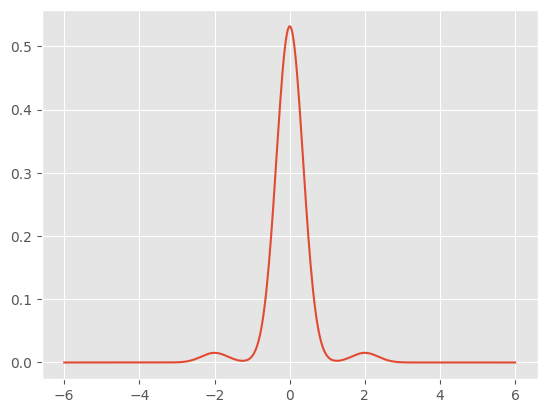

In [113]:
plt.plot(xs, cond_dens)

In [90]:
from emcee import EnsembleSampler

nwalkers = 16
ndim = 1
nsteps = 25000
initial = np.random.randn(nwalkers, ndim)
sampler = EnsembleSampler(nwalkers, ndim, log_eight_gaussians_cond)
sampler.run_mcmc(initial, nsteps, progress=True);

100%|██████████| 25000/25000 [00:12<00:00, 1934.48it/s]


<Axes: ylabel='Density'>

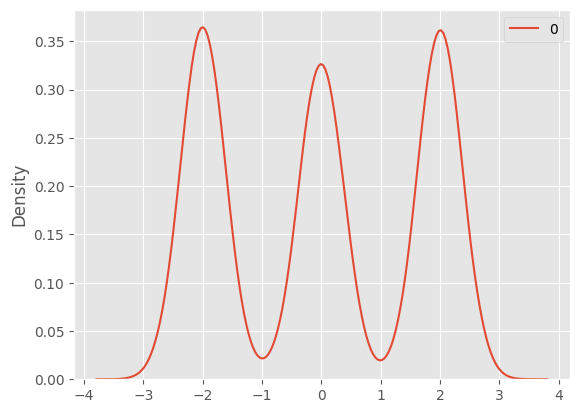

In [91]:
kdeplot(np.vstack(sampler.chain))

In [114]:
tau = 5.0
cond_variable = -2.95
from scipy.optimize import minimize_scalar

def log_gauss(u):
    # u = float(u)
    # IMPORTANT: include normalization if you want M for rejection sampling
    return -0.5*(u*u)/(tau*tau) - 0.5*np.log(2*np.pi*tau*tau)

def neg_log_ratio(u):
    return -(log_eight_gaussians_cond(u) - log_gauss(u))


res = minimize_scalar(neg_log_ratio, bounds=(-50, 50), method="bounded")
u_star = res.x
max_log_ratio = -res.fun
M = np.exp(max_log_ratio)

/tmp/ipykernel_658567/1731938589.py:48: RuntimeWarning: divide by zero encountered in log
  return float(np.log(eight_gaussians_cond(u)))


In [115]:
def rejection_sample(n, tau=5.0, bounds=(-50, 50), batch=4096, seed=0):
    rng = np.random.default_rng(seed)

    log_m = np.log(M)
    samples = []
    n_accepted = 0
    n_total = 0

    while n_accepted < n:
        # propose a batch from q
        u_prop = rng.normal(loc=0.0, scale=tau, size=batch)

        # log acceptance ratios
        log_alpha = np.array([log_eight_gaussians_cond(u) - log_gauss(u) - log_m for u in u_prop])

        # accept with probability exp(log_alpha) (clipped at 1 for safety)
        alpha = np.exp(np.minimum(log_alpha, 0.0))
        u = rng.uniform(size=batch)
        accept = u < alpha

        accepted = u_prop[accept]
        samples.append(accepted)

        n_total += batch
        n_accepted += accepted.size

    samples = np.concatenate(samples)[:n]
    accept_rate = n / n_total

    return samples, accept_rate

samps, accept_rate = rejection_sample(100000)

/tmp/ipykernel_658567/1731938589.py:48: RuntimeWarning: divide by zero encountered in log
  return float(np.log(eight_gaussians_cond(u)))


In [118]:
np.save("rej_samples_3.npy", samps)

In [117]:
accept_rate

0.07466074159021406

<Axes: ylabel='Density'>

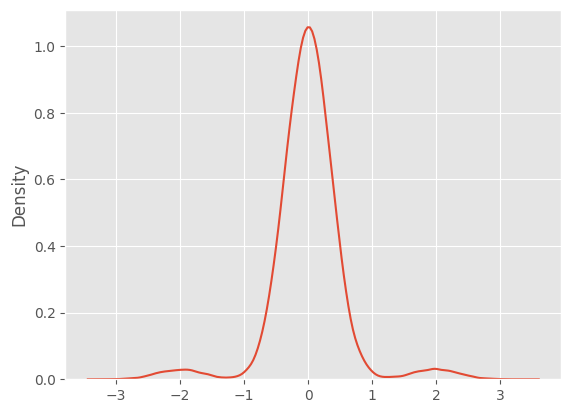

In [116]:
kdeplot(samps)